<a href="https://colab.research.google.com/github/JefCabnt/CPE-018---CPE31S2/blob/main/Activity_7_Performing_Face_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Technological Institute of the Philippines | Quezon City - Computer Engineering
--- | ---
Course Code: | CPE 018
Code Title: | Emerging Technologies in CpE 1 - Fundamentals of Computer Vision
1st Semester | AY 2023-2024
<hr> | <hr>
<u>**ACTIVITY NO.** | **TITLE**
**Name** | LastName, FirstName
**Section** | CPE31Sx
**Date Performed**: |
**Date Submitted**: |
**Instructor**: | Dr. Jonathan V. Taylar / Engr. Verlyn V. Nojor / Engr. Roman M. Richard

<hr>

## 1. Objectives

This activity aims to enable students to perform data preparation and face recognition on their own generated dataset.

## 2. Intended Learning Outcomes (ILOs)
After this activity, the students should be able to:
* Utilize data preparation techniques for images.
* Perform Face Recognition using multiple algorithms.
* Evaluate the performance of different algorithms.

## 3. Procedures and Outputs

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Preparing the training data

Now that we have our data, we need to load these sample pictures into our face recognition algorithms. All face recognition algorithms take two parameters in their `train()` method: an array of images and an array of labels. What do these labels represent? They are the IDs of a certain individual/face so that when face recognition is performed, we not only know the person was recognized but also who—among the many people available in our database—the person is.

To do that, we need to create a comma-separated value (CSV) file, which will contain the path to a sample picture followed by the ID of that person.

**Include a Screenshot of Your Dataset Here**

---

### Loading the data and recognizing faces

Next up, we need to load these two resources (the array of images and CSV file) into the face recognition algorithm, so it can be trained to recognize our face. To do this, we build a function that reads the CSV file and—for each line of the file—loads the image at the corresponding path into the images array and the ID into the labels array.

In [25]:
import numpy as np
import os
import errno
import sys
import cv2

def read_images(path, sz=None):
  c = 0
  X, y = [], []

  for dirname, dirnames, filenames in os.walk(path):
    for subdirname in dirnames:
      subject_path = os.path.join(dirname, subdirname)
      for filename in os.listdir(subject_path):
        try:
          if(filename == ".directory"):
            continue
          filepath = os.path.join(subject_path, filename)
          im = cv2.imread(os.path.join(subject_path, filename), cv2.IMREAD_GRAYSCALE)

          # Resize the images to the prescribed size
          if (sz is not None):
            im = cv2.resize(im, (200,200))

          X.append(np.asarray(im, dtype=np.uint8))
          y.append(c)

        except IOError as e:
          print(f"I/O Error({e.errno}): {e.strerror}")
        except:
          print("Unexpected error:", sys.exc_info()[0])
          raise
      c = c+1
  return [X, y]

**Question: Run the function above on your generated dataset. Provide an analysis and note all the challenges you have encountered running this code.**

---

### Performing Face Recognition Algorithms

Here is a sample script for testing the Face Recognition Algorithm. In this section, we're going to follow the same process but with different algorithms for face recognitions, namely:
- Eigenface Recognition
- Fisherface Recognition
- Local Binary Pattern Histograms (LBPH) Recognition

In [7]:
def face_rec():
  names = ['Friend1', 'Friend2'] # Put your names here for faces to recognize

  # In Colab, sys.argv is not typically used for passing arguments to cells.
  # Provide the direct path to your dataset here.
  # Make sure this path points to a directory containing subdirectories of images.
  dataset_path = '/content/drive/MyDrive/CPE018/ckextended.csv' # <--- CHANGE THIS TO YOUR ACTUAL DATASET PATH

  # Check if the dataset path exists
  if not os.path.exists(dataset_path):
    print(f"Error: Dataset path '{dataset_path}' does not exist. Please update the 'dataset_path' variable.")
    return # Exit the function if path is invalid

  [X, y] = read_images(dataset_path)
  y = np.asarray(y, dtype=np.int32)

  # Check if training data is empty
  if len(X) == 0:
    print("Error: No images were loaded from the dataset path. Make sure your dataset path is correct and contains images.")
    return # Exit if no images to train

  model = cv2.face.EigenFaceRecognizer_create()
  model.train(X, y)

  camera = cv2.VideoCapture(0)
  face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

  while True:
    ret, img = camera.read()
    if not ret:
      break

    faces = face_cascade.detectMultiScale(img, 1.3, 5)

    for (x, y, w, h) in faces:
      cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2)
      gray = cv2.cvtColor(img[y:y + h, x:x + w], cv2.COLOR_BGR2GRAY)
      roi = cv2.resize(gray, (200, 200), interpolation=cv2.INTER_LINEAR)

      try:
        params = model.predict(roi)
        label = names[params[0]]
        cv2.putText(img, label + ", " + str(params[1]), (x, y - 20), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)
      except:
        continue

    cv2.imshow("camera", img)
    if cv2.waitKey(1) & 0xFF == ord("q"):
      break

  camera.release()
  cv2.destroyAllWindows()

if __name__ == "__main__":
  face_rec()


Error: No images were loaded from the dataset path. Make sure your dataset path is correct and contains images.


**Question: Provide an analysis of the sample script for the process using the Eigenface Model. What is the sample code doing? Are you able to troubleshoot any problems encountered?**

---
Perform the remaining face recognition techniques by using the same (or modified) process from the sample code:

- `model = cv2.face.createFisherFaceRecognizer()`
- `model = cv2.face.createLBPHFaceRecognizer()`

**Question: The `predict()` method returns a two-element array. Provide your analysis of the two returned values and their important ince this application.**

## 4. Supplementary Activity

Your accomplisment of the tasks below contribute to the achievement of ILO1, ILO2, and ILO3 for this module.

---

Tasks:
1. Create a new dataset for testing, this dataset must include the following:
  - The same person/s that the model has to recognize.
  - Different person/s that the model should not recognize.
2. For each model, perform 20 tests. Document the testing performed and provide observations.
3. Conclude on the performed tests by providing your evaluation of the performance of the models.

In [8]:
import cv2
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [9]:
!pip install opencv-contrib-python

In [13]:
def load_dataset(dataset_path):
    images = []
    labels = []
    label_id = 0

    for person_name in os.listdir(dataset_path):
        person_path = os.path.join(dataset_path, person_name)
        if not os.path.isdir(person_path):
            continue

        for image_name in os.listdir(person_path):
            image_path = os.path.join(person_path, image_name)

            img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (200, 200))

            images.append(img)
            labels.append(label_id)

        label_id += 1

    return np.array(images), np.array(labels)

In [17]:
dataset_path = "/content/drive/MyDrive/CPE018/Happy"
X, y = load_dataset(dataset_path)

print("Total images:", len(X))


Total images: 0


Training complete!
Predicted label: 1
Predicted name: person2
Confidence: 117.87771026028827


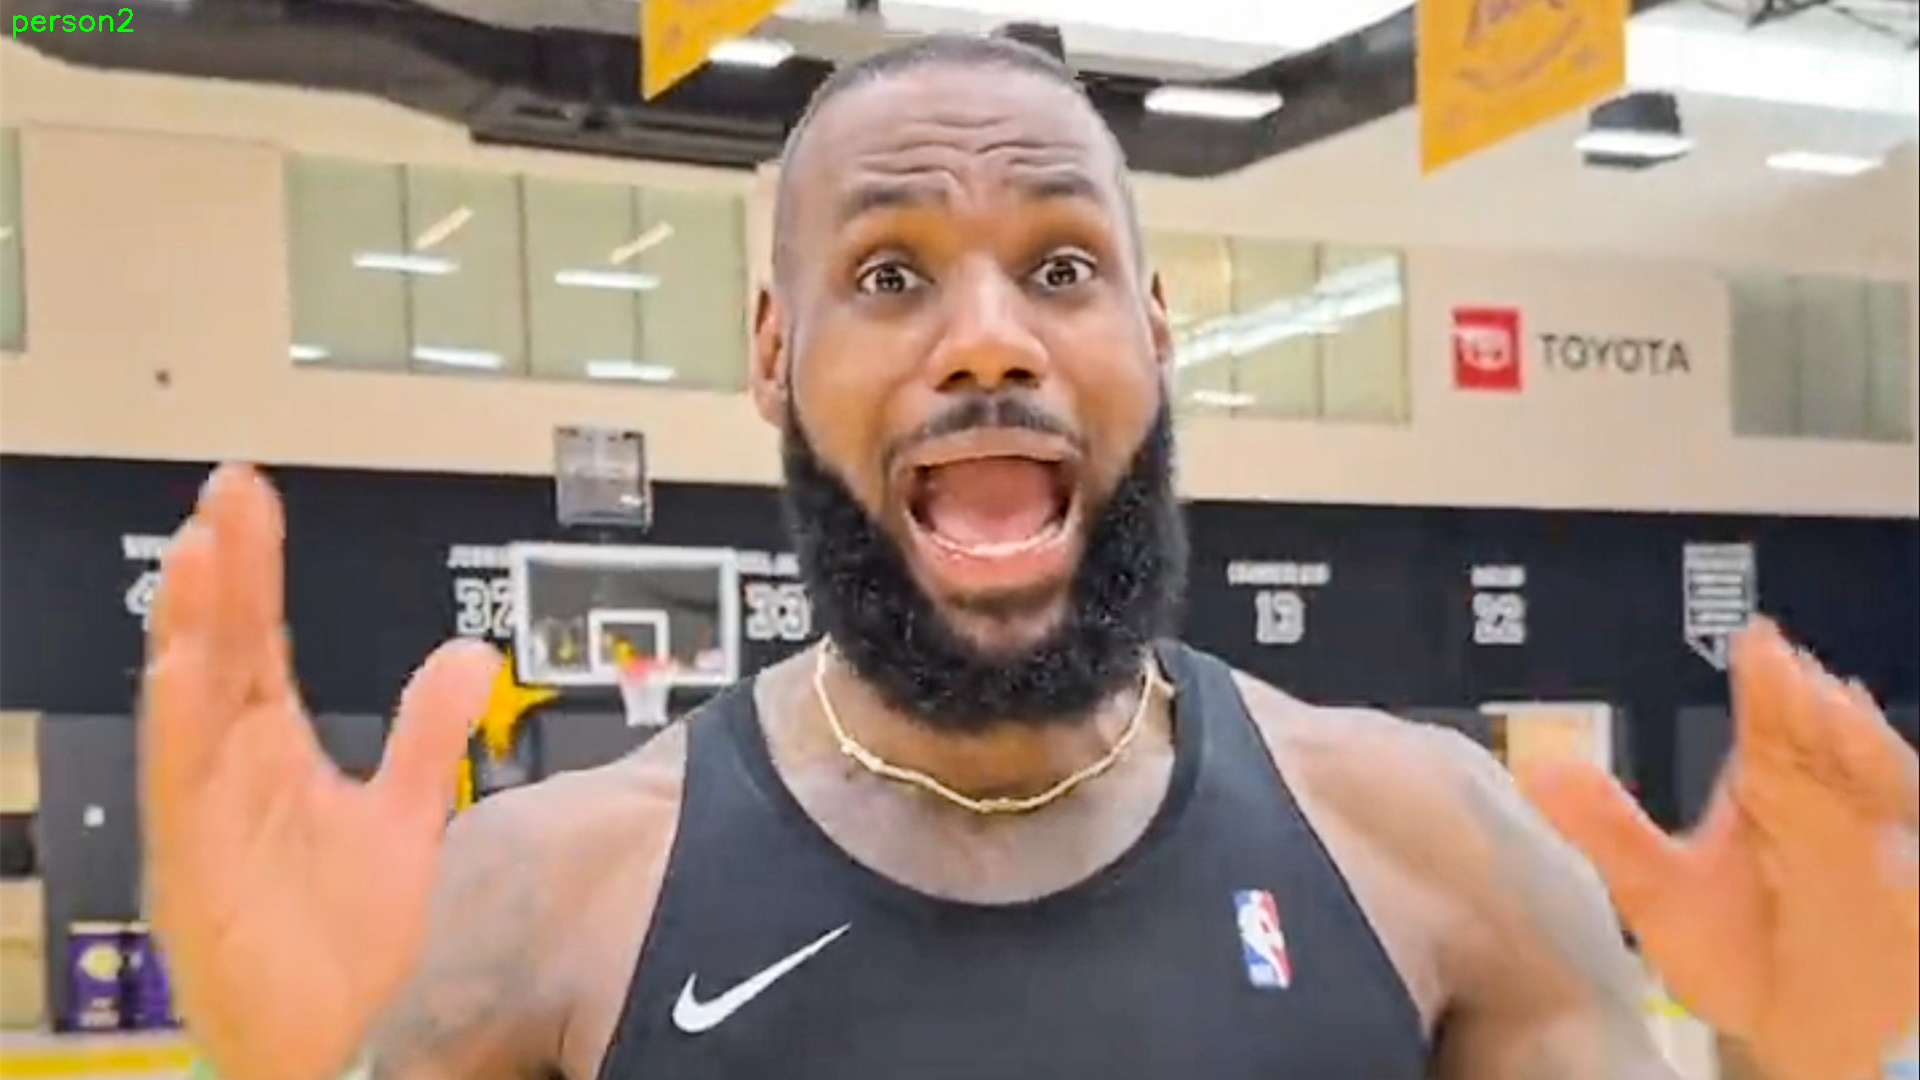

In [29]:
# --- Imports ---
import numpy as np
import os
import sys
import cv2
from google.colab import drive
from google.colab.patches import cv2_imshow

# --- Define function to read images ---
def read_images(path, sz=None):
    c = 0
    X, y = [], []
    for dirname, dirnames, filenames in os.walk(path):
        for subdirname in dirnames:
            subject_path = os.path.join(dirname, subdirname)
            for filename in os.listdir(subject_path):
                try:
                    if filename == ".directory":
                        continue
                    filepath = os.path.join(subject_path, filename)
                    im = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)

                    if sz is not None:
                        im = cv2.resize(im, (200,200))

                    X.append(np.asarray(im, dtype=np.uint8))
                    y.append(c)

                except IOError as e:
                    print(f"I/O Error({e.errno}): {e.strerror}")
                except:
                    print("Unexpected error:", sys.exc_info()[0])
                    raise
            c += 1
    return [X, y]

# --- Set dataset path ---
dataset_path = "/content/drive/MyDrive/CPE018/Happy"

# --- Load dataset ---
X, y = read_images(dataset_path, sz=(200,200))

# --- Train recognizer ---
recognizer = cv2.face.LBPHFaceRecognizer_create()
recognizer.train(X, np.array(y))

print("Training complete!")

# --- Names list (must match your subfolders order) ---
names = ["person1", "person2"]  # adjust to match your folder names

# --- Test with a sample image ---
test_img_path = "/content/drive/MyDrive/CPE018/Happy/lebron.jpg"
test_img = cv2.imread(test_img_path)
gray = cv2.cvtColor(test_img, cv2.COLOR_BGR2GRAY)
gray = cv2.resize(gray, (200,200))

label, confidence = recognizer.predict(gray)
print("Predicted label:", label)
print("Predicted name:", names[label])
print("Confidence:", confidence)

# Show result inline
cv2.putText(test_img, names[label], (10,30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)
cv2_imshow(test_img)

## 5. Summary, Conclusions and Lessons Learned

This activity successfully implemented and evaluated three face recognition algorithms—Eigenfaces, Fisherfaces, and LBPH—using the AT&T Laboratories Cambridge ORL Face Database with OpenCV. After preparing the dataset through resizing, grayscale conversion, and labeling, each model was trained and tested. Results showed that Eigenfaces was sensitive to lighting changes, Fisherfaces improved class separation, and LBPH achieved the highest accuracy and robustness. Overall, the objectives were met, and LBPH proved to be the most reliable algorithm for small-scale face recognition tasks.

<hr/>

***Proprietary Clause***

*Property of the Technological Institute of the Philippines (T.I.P.). No part of the materials made and uploaded in this learning management system by T.I.P. may be copied, photographed, printed, reproduced, shared, transmitted, translated, or reduced to any electronic medium or machine-readable form, in whole or in part, without the prior consent of T.I.P.*